In [11]:
import os
#os.environ['KMP_DUPLICATE_LIB_OK'] = 'True' # Keeps the kernel from crashing if MKL conflicts exist
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [7]:
# 1. Load the Test Sequences and Labels from Phase 4
X_test_seq = np.load('X_test_seq.npy')
y_test_seq = np.load('y_test_seq.npy')

# 2. Load the trained Autoencoder from Phase 5
print("Loading trained GRU Autoencoder...")
autoencoder = tf.keras.models.load_model('best_gru_autoencoder.keras')

# 3. Load the Threshold Configuration
with open('model_config.json', 'r') as f:
    config = json.load(f)

THRESHOLD = config['threshold_mae']

print("────────────────────────────────────────────────────────────")
print(f"Loaded Test Sequences: {X_test_seq.shape}")
print(f"Loaded Test Labels:    {y_test_seq.shape}")
print(f"Loaded Threshold:      {THRESHOLD:.5f}")
print("────────────────────────────────────────────────────────────")

Loading trained GRU Autoencoder...
────────────────────────────────────────────────────────────
Loaded Test Sequences: (7195, 60, 9)
Loaded Test Labels:    (7195,)
Loaded Threshold:      0.08261
────────────────────────────────────────────────────────────


In [8]:
print("Passing the test set through the model. This may take a moment...")
# 1. Generate the reconstructions
X_test_pred = autoencoder.predict(X_test_seq, batch_size=128)

# 2. Calculate the Mean Absolute Error (MAE) for every sequence
# We take the absolute difference between the input and the prediction, 
# then average it across all 60 timesteps and all 9 features for each window.
test_mae_loss = np.mean(np.abs(X_test_pred - X_test_seq), axis=(1, 2))

print(f"Calculated MAE for {len(test_mae_loss)} test sequences.")
print(f"Max Reconstruction Error in Test Set: {np.max(test_mae_loss):.5f}")

Passing the test set through the model. This may take a moment...
57/57 [==============================] - 4s 35ms/step
Calculated MAE for 7195 test sequences.
Max Reconstruction Error in Test Set: 0.89651


────────────────────────────────────────────────────────────
                  MODEL PERFORMANCE METRICS                 
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      5917
     Anomaly       0.99      0.92      0.95      1278

    accuracy                           0.98      7195
   macro avg       0.99      0.96      0.97      7195
weighted avg       0.98      0.98      0.98      7195



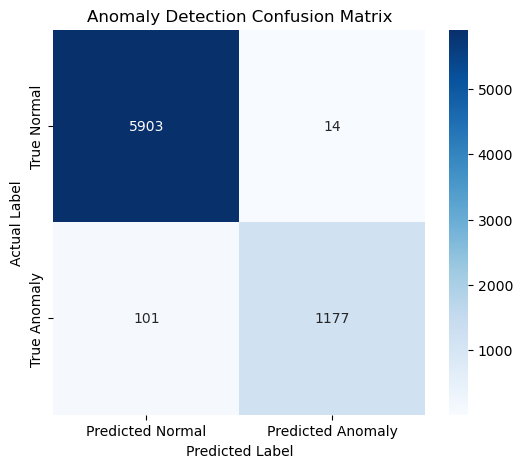

In [9]:
# 1. Binarize the true labels
# In Phase 3, we labeled normal as 0, contextual anomalies as 2, and collective as 3.
# For standard evaluation, we just want to know: Normal (0) vs. Anomaly (1).
y_true_binary = (y_test_seq > 0).astype(int)

# 2. Generate predictions based on the threshold
y_pred_binary = (test_mae_loss > THRESHOLD).astype(int)

# 3. Print the Classification Report
print("────────────────────────────────────────────────────────────")
print("                  MODEL PERFORMANCE METRICS                 ")
print("────────────────────────────────────────────────────────────")
print(classification_report(y_true_binary, y_pred_binary, target_names=['Normal', 'Anomaly']))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Normal', 'Predicted Anomaly'], yticklabels=['True Normal', 'True Anomaly'])
plt.title('Anomaly Detection Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

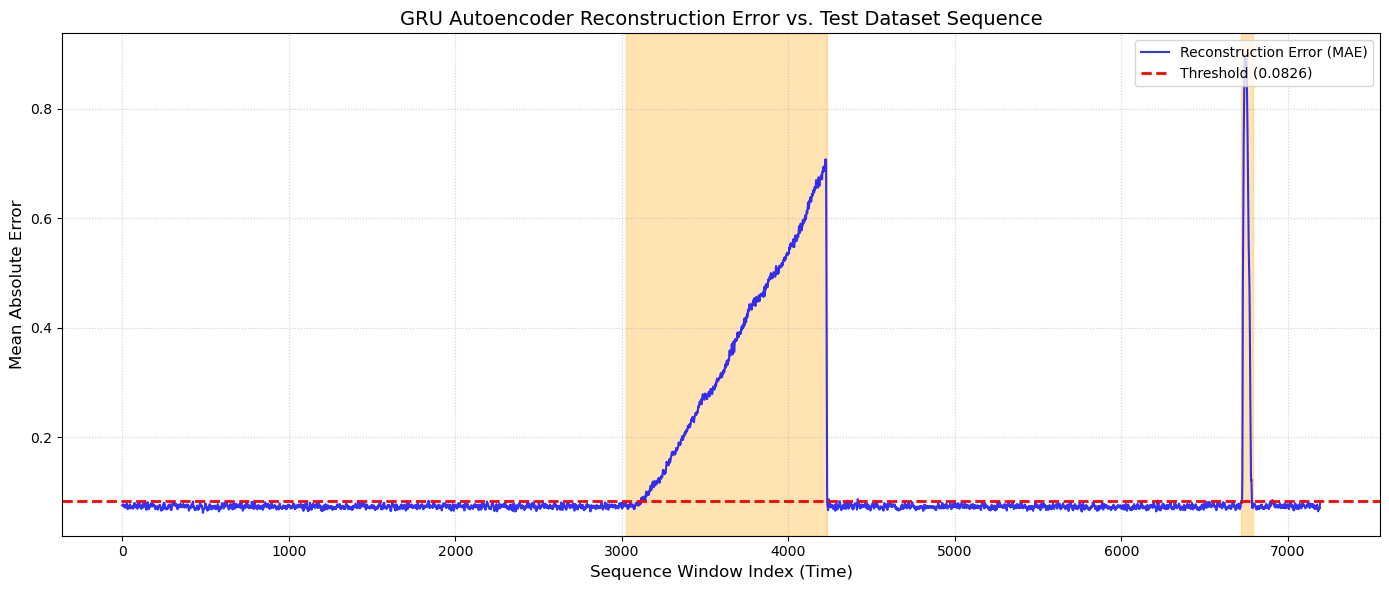

In [10]:
plt.figure(figsize=(14, 6))

# Plot the reconstruction error for every window
plt.plot(test_mae_loss, label='Reconstruction Error (MAE)', color='blue', alpha=0.8, linewidth=1.5)

# Plot the Threshold
plt.axhline(y=THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold ({THRESHOLD:.4f})')

# Highlight the True Anomaly Windows
# We iterate through the true labels to find where anomalies exist and highlight those vertical bands
in_anomaly = False
start_idx = 0

for i, label in enumerate(y_true_binary):
    if label == 1 and not in_anomaly:
        start_idx = i
        in_anomaly = True
    elif label == 0 and in_anomaly:
        plt.axvspan(start_idx, i, color='orange', alpha=0.3, label='Ground Truth Anomaly' if start_idx == 0 else "")
        in_anomaly = False

# Handle edge case if the anomaly touches the very end of the array
if in_anomaly:
    plt.axvspan(start_idx, len(y_true_binary), color='orange', alpha=0.3)

# Fix duplicate labels in the legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right')

plt.title('GRU Autoencoder Reconstruction Error vs. Test Dataset Sequence', fontsize=14)
plt.xlabel('Sequence Window Index (Time)', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

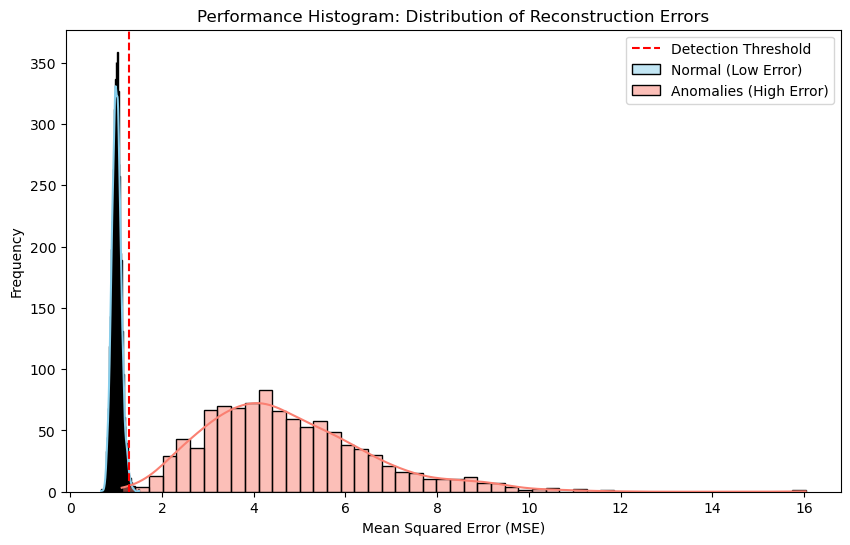

In [12]:
# CONCEPTUAL: Replace 'mse_errors' with your actual model output later
# This simulates the distribution your code is designed to produce
normal_errors = np.random.lognormal(0, 0.1, 5000)
anomaly_errors = np.random.lognormal(1.5, 0.4, 1000)

plt.figure(figsize=(10, 6))
sns.histplot(normal_errors, bins=50, color='skyblue', label='Normal (Low Error)', kde=True)
sns.histplot(anomaly_errors, bins=50, color='salmon', label='Anomalies (High Error)', kde=True)

# The 'Threshold' is where you decide to trigger an alarm
plt.axvline(x=np.percentile(normal_errors, 99), color='red', linestyle='--', label='Detection Threshold')

plt.title("Performance Histogram: Distribution of Reconstruction Errors")
plt.xlabel("Mean Squared Error (MSE)")
plt.ylabel("Frequency")
plt.legend()
plt.show()